<a href="https://colab.research.google.com/github/filfish2007-cav/ITStep-AI/blob/superwised_learning/Practice_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [1]:
import pandas as pd


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/car_price.csv")

In [ ]:
df.head()

,mileage,age,engine,horsepower,num_previous_owners,price
0,60675,4,1.6,228,1,18421
1,23671,24,1.7,179,1,11279
2,82893,5,2.3,115,1,10279
3,94692,11,2.4,94,1,9876
4,12509,9,1.8,126,0,19428


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4760 entries, 0 to 4759
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mileage              4760 non-null   int64  
 1   age                  4760 non-null   int64  
 2   engine               4760 non-null   float64
 3   horsepower           4760 non-null   int64  
 4   num_previous_owners  4760 non-null   int64  
 5   price                4760 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 223.3 KB


# Опис даних

- **mileage** — пробіг автомобіля в кілометрах
- **age** — вік автомобіля в роках
- **engine** — об'єм двигуна автомобіля в літрах
- **horsepower** — потужність двигуна в кінських силах
- **num_previous_owners** — кількість попередніх власників автомобіля
- **price** — ціна автомобіля

Потрібно спрогнозувати **ціну** автомобіля

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [6]:
from sklearn.model_selection import train_test_split

y = df['price']
X = df.drop('price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3808, 5)
X_test shape: (952, 5)
y_train shape: (3808,)
y_test shape: (952,)


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [8]:
from sklearn.tree import DecisionTreeRegressor

model_tree = DecisionTreeRegressor()
model_tree.fit(X_train, y_train)


DecisionTreeRegressor()

# Завдання 4
Спронозуйте ціну автомобіля для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model_tree.predict(X_train)

mae = mean_absolute_error(y_train, pred)
mse = mean_squared_error(y_train, pred)
r2 = r2_score(y_train, pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")



MAE: 0.0
MSE: 0.0
R2: 1.0


# Завдання 5
Спронозуйте ціну автомобіля для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model_tree.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")

MAE: 3020.625
MSE: 14418079.851890756
R2: 0.5371994584512704


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [17]:
train_mae = []
test_mae = []

max_depths = range(1,15)

for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  pred_train = tree.predict(X_train)
  pred_test = tree.predict(X_test)

  mae_train = mean_absolute_error(y_train, pred_train)
  mae_test = mean_absolute_error(y_test, pred_test)

  train_mae.append(mae_train)
  test_mae.append(mae_test)

test_mae

[3865.5684419801573,
 3276.1329386307693,
 2841.451556037191,
 2582.0253313989588,
 2434.323528219818,
 2371.0694897265494,
 2353.166857375877,
 2318.360904232459,
 2319.089990552102,
 2470.092390193563,
 2576.6675698708136,
 2649.422318826061,
 2738.414051160205,
 2816.090040729073]

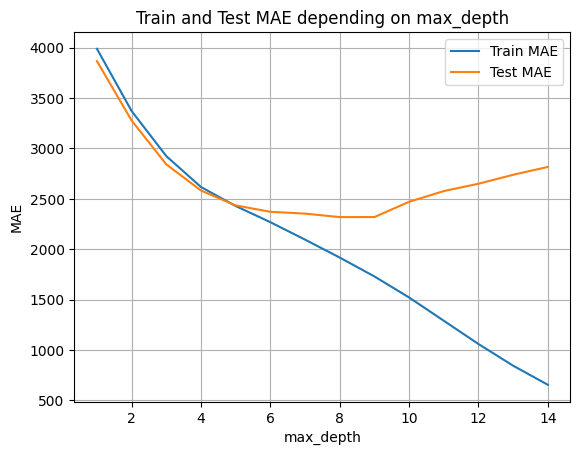

In [18]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

# Завдання 8
Побудуйте такіж графіки для метрик MSE та R2

In [19]:
train_mse = []
test_mse = []

max_depths = range(1,15)

for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  pred_train = tree.predict(X_train)
  pred_test = tree.predict(X_test)

  mse_train = mean_squared_error(y_train, pred_train)
  mse_test = mean_squared_error(y_test, pred_test)

  train_mse.append(mse_train)
  test_mse.append(mse_test)

test_mse

[23348226.35079933,
 16409452.185000427,
 12869443.875461118,
 10411550.874377279,
 9395824.679634908,
 8872732.143304897,
 8880136.161695283,
 8609634.897061927,
 8608079.810489656,
 9426474.7549215,
 10503780.207968893,
 11514926.6064766,
 11891675.621280562,
 12215527.323324485]

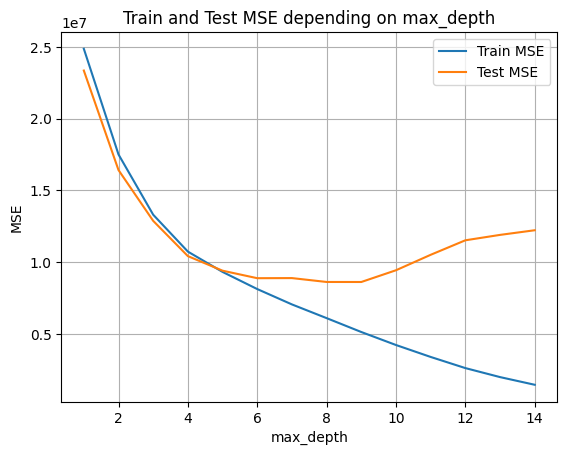

In [20]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mse, label="Train MSE")
plt.plot(max_depths, test_mse, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MSE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [21]:
train_r2 = []
test_r2 = []

max_depths = range(1,15)

for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  pred_train = tree.predict(X_train)
  pred_test = tree.predict(X_test)

  r2_train = r2_score(y_train, pred_train)
  r2_test = r2_score(y_test, pred_test)

  train_r2.append(r2_train)
  test_r2.append(r2_test)

test_r2

[0.2505540328287731,
 0.4732791442585691,
 0.5869085442599118,
 0.6658035305310042,
 0.698406944981532,
 0.7151974962602364,
 0.714704583111994,
 0.7223785980521977,
 0.7131451841545744,
 0.690440629402778,
 0.6643675026156297,
 0.6417311385360283,
 0.6168065189965549,
 0.6002300872485988]

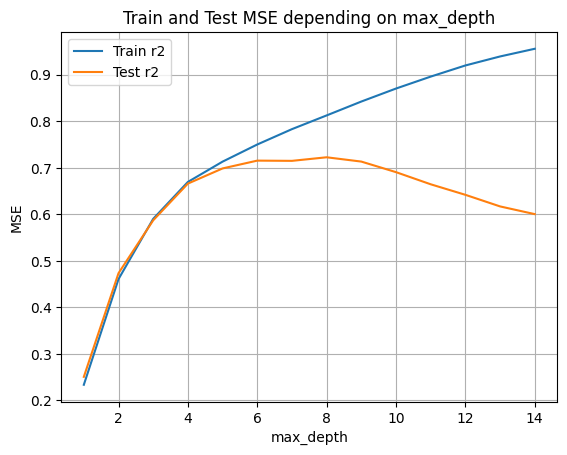

In [22]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_r2, label="Train r2")
plt.plot(max_depths, test_r2, label="Test r2")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MSE depending on max_depth")
plt.legend()
plt.grid()

plt.show()